# Wstępna eksploracja przestrzeni parametrów

## Topologia meeting (sieci o strukturze społeczności)

In [42]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "./results/exploration_v1"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting-200-5.csv
meeting-300-5.csv
meeting-100-5.csv
meeting-50-5.csv
meeting-500-5.csv
meeting-300-5_2.csv
meeting-500-5_2.csv

Total rows: 148


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
0,16,meeting,200,5,5,5,500,0.0005,1.0,0.001,0.8,208.749015,147.829984,meeting-200-5.csv
1,18,meeting,200,5,5,5,500,0.0010,1.0,0.001,0.8,208.509309,145.618709,meeting-200-5.csv
2,17,meeting,200,5,5,5,500,0.0005,2.0,0.001,0.8,202.959956,124.867465,meeting-200-5.csv
3,19,meeting,200,5,5,5,500,0.0010,2.0,0.001,0.8,203.742068,124.867465,meeting-200-5.csv
4,20,meeting,200,5,5,10,500,0.0005,1.0,0.001,0.8,227.074411,134.306445,meeting-200-5.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'average', 'best', 'source_file']


In [6]:
# ============================================================
# MEAN RESULTS BY NUMBER OF ISLANDS
# ============================================================

df_mean = (
    df_meeting.groupby("number_of_islands", as_index=False)
    .agg({
        "best": "mean",
        "average": "mean",
    })
)

display(df_mean)

,number_of_islands,best,average
0,50,273.050723,312.805340
1,100,220.874301,304.710534
2,200,134.450687,215.257790
3,300,87.083745,139.576201
4,500,68.101952,112.227768


/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_86532/845645730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


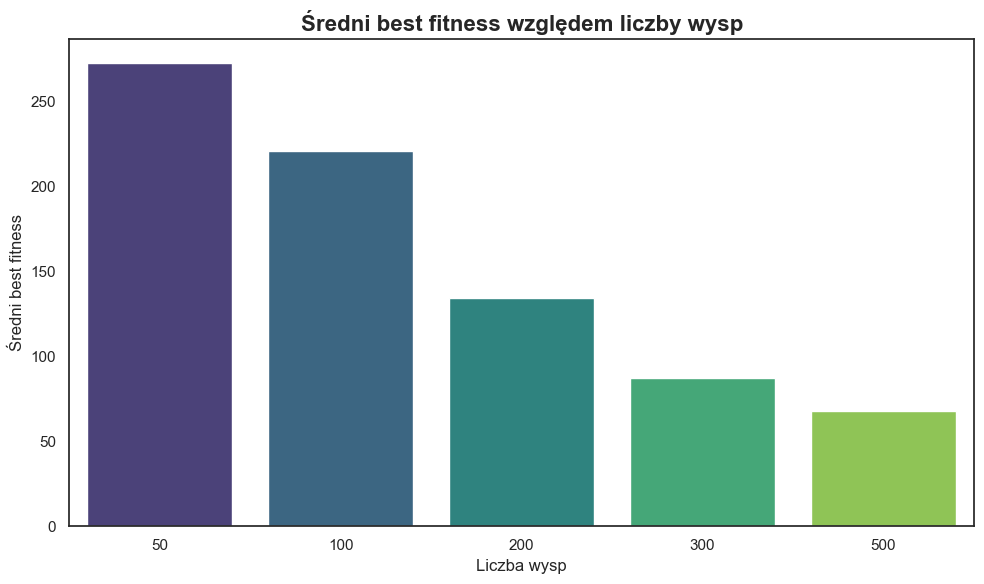

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mean,
    x="number_of_islands",
    y="best",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.tight_layout()
plt.show()

/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_86532/289990158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


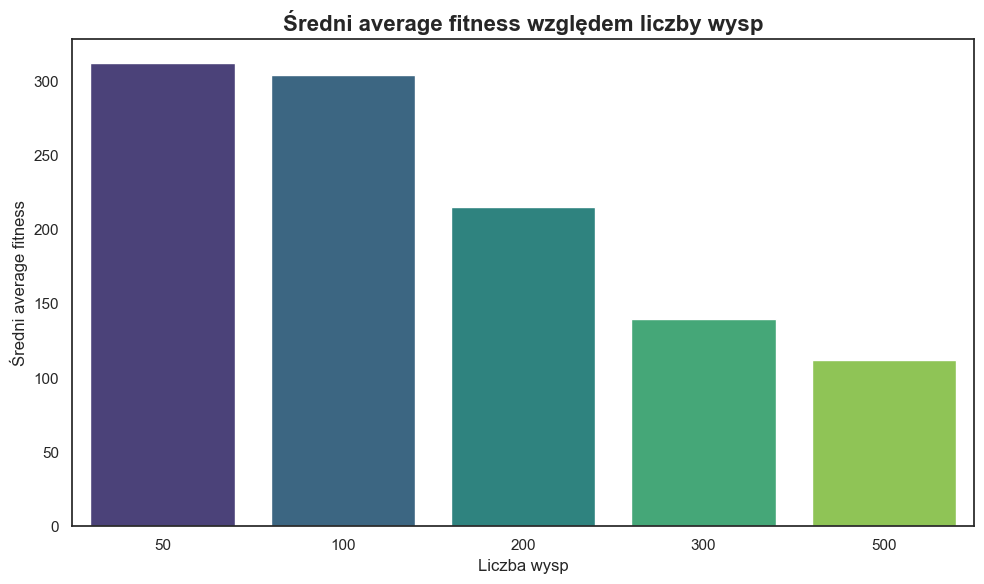

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mean,
    x="number_of_islands",
    y="average",
    palette="viridis",
)

plt.title(
    "Średni average fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni average fitness")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# BEST CONFIGURATION FOR EACH NUMBER OF ISLANDS
# ============================================================

idx = df_meeting.groupby("number_of_islands")["best"].idxmin()

df_best_configs = df_meeting.loc[idx].sort_values("number_of_islands")

display(df_best_configs)

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
75,4,meeting,50,5,5,10,500,0.0005,1.0,0.001,0.8,279.550641,252.607229,meeting-50-5.csv
67,14,meeting,100,5,5,10,500,0.0010,1.0,0.001,0.8,320.186768,200.337405,meeting-100-5.csv
7,23,meeting,200,5,5,10,500,0.0010,2.0,0.001,0.8,196.038053,117.310979,meeting-200-5.csv
58,50,meeting,300,5,5,10,1000,0.0010,2.0,0.005,0.8,122.932430,66.554952,meeting-300-5.csv
116,92,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,74.559198,40.757107,meeting-500-5.csv


In [10]:
important_cols = [
    "number_of_islands",
    "best",
    "average",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma",
]

display(df_best_configs[important_cols])

,number_of_islands,best,average,z_star,n_steps,r0,r1,gamma
75,50,252.607229,279.550641,10,500,0.0005,1.0,0.001
67,100,200.337405,320.186768,10,500,0.0010,1.0,0.001
7,200,117.310979,196.038053,10,500,0.0010,2.0,0.001
58,300,66.554952,122.932430,10,1000,0.0010,2.0,0.005
116,500,40.757107,74.559198,10,1000,0.0005,1.0,0.005


In [11]:
# 10 best configurations for meeting globally
top10_meeting = (
    df_meeting
    .sort_values("best")
    .head(10)
)

display(top10_meeting[important_cols])

,number_of_islands,best,average,z_star,n_steps,r0,r1,gamma
116,500,40.757107,74.559198,10,1000,0.00050,1.0,0.0050
125,500,41.976226,85.165508,10,1000,0.00100,1.0,0.0050
145,500,45.813507,81.478631,10,500,0.00100,1.0,0.0010
129,500,46.901369,79.978807,10,1000,0.00100,3.0,0.0005
117,500,47.636605,87.300664,10,1000,0.00050,2.0,0.0005
120,500,48.846811,94.906581,10,1000,0.00050,3.0,0.0005
110,500,50.358125,89.514222,10,1000,0.00025,2.0,0.0050
131,500,51.592144,96.145882,10,1000,0.00100,3.0,0.0050
144,500,52.599184,88.496193,10,500,0.00050,1.0,0.0010
106,500,53.186112,84.827507,10,1000,0.00025,1.0,0.0010


## Analiza parametrów

In [12]:
df_zstar = (
    df_meeting.groupby("z_star", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_zstar)

z_star        best                                       average  \
                mean        min         max        std        mean   
0      5  107.949068  65.789570  268.721847  52.477542  160.719799   
1     10   90.003890  40.757107  292.914337  58.399642  140.280679   

                                      
          min         max        std  
0  109.938320  334.818162  54.146669  
1   74.559198  330.409849  69.382026

In [13]:
df_r0 = (
    df_meeting.groupby("r0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_r0)

r0        best                                       average  \
                  mean        min         max        std        mean   
0  0.00025   78.188678  50.358125  111.957236  15.441632  127.455395   
1  0.00050  106.935377  40.757107  277.614342  61.874620  159.569697   
2  0.00100  104.381167  41.976226  292.914337  63.570420  156.245324   

                                     
         min         max        std  
0  84.827507  159.642875  23.504696  
1  74.559198  334.818162  69.675588  
2  79.884581  323.923797  69.932159

In [14]:
df_r1 = (
    df_meeting.groupby("r1", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_r1)

r1        best                                       average             \
              mean        min         max        std        mean        min   
0  1.0  105.732565  40.757107  292.914337  62.568727  159.639638  74.559198   
1  2.0  105.285267  47.636605  286.382492  62.856843  157.345374  79.884581   
2  3.0   78.653342  46.901369  111.957236  16.598175  125.635408  79.978807   

                          
          max        std  
0  334.818162  68.808556  
1  330.409849  70.778336  
2  157.557833  20.980112

In [15]:
df_gamma = (
    df_meeting.groupby("gamma", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_gamma)

gamma        best                            average             \
                 mean        min         max        mean        min   
0  0.0005   78.915115  46.901369  100.901664  127.718519  79.978807   
1  0.0010  119.200344  45.813507  292.914337  173.557576  81.478631   
2  0.0050   76.343016  40.757107  103.893597  124.605359  74.559198   

               
          max  
0  158.532766  
1  334.818162  
2  158.256393

In [16]:
df_n_steps = (
    df_meeting.groupby("n_steps", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_n_steps)

n_steps        best                            average             \
                 mean        min         max        mean        min   
0     500  156.172855  45.813507  292.914337  217.397134  81.478631   
1    1000   77.792636  40.757107  111.957236  125.723611  74.559198   

               
          max  
0  334.818162  
1  159.642875

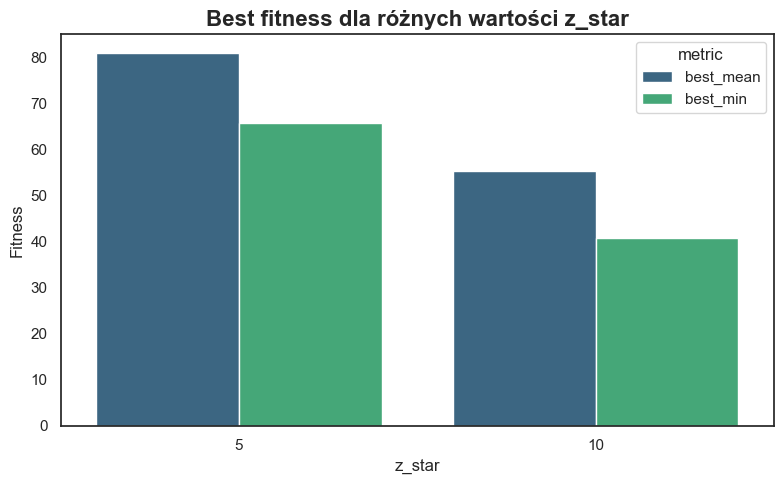

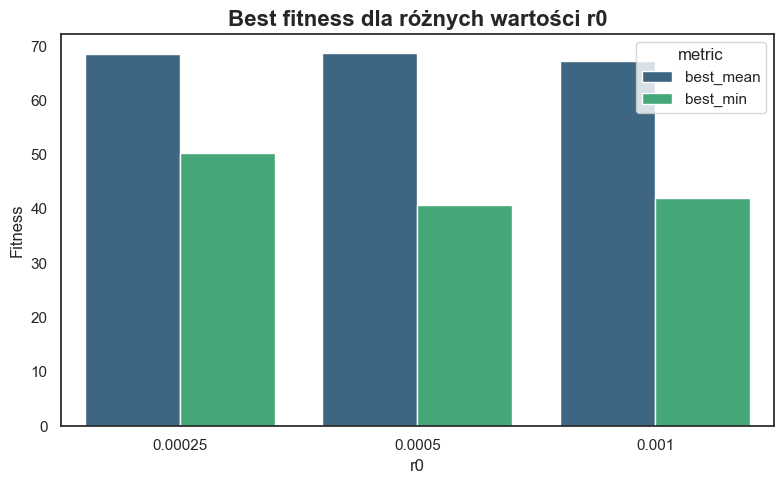

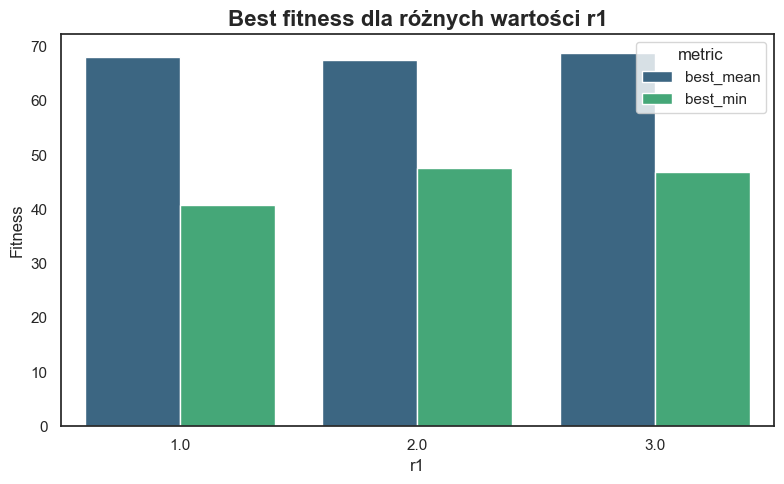

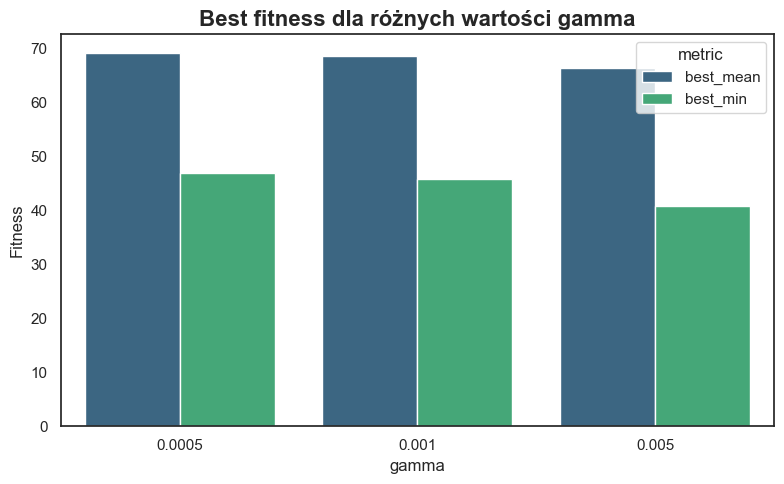

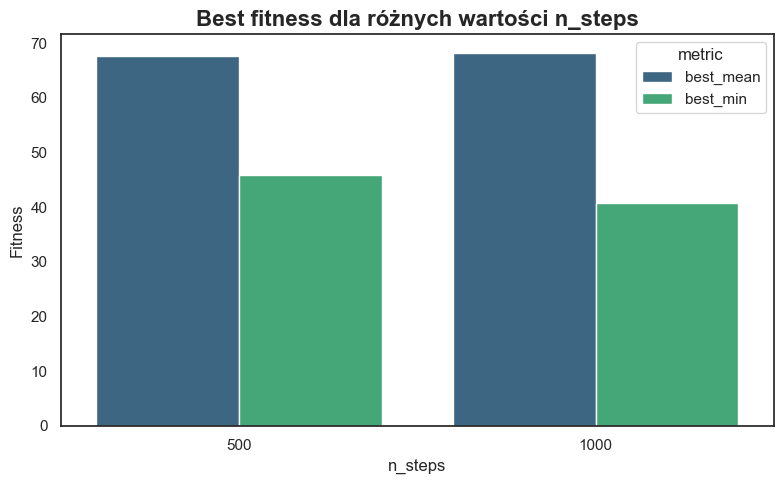

In [17]:
for param in ['z_star', 'r0', 'r1', 'gamma', 'n_steps']:

    df = (
        df_meeting[df_meeting['number_of_islands']==500].groupby(param, as_index=False)
        .agg({
            "best": ["mean", "min"],
        })
    )

    # spłaszczenie nazw kolumn
    df.columns = [
        "_".join(col).strip("_")
        for col in df.columns.values
    ]

    plot_df = df.melt(
        id_vars=param,
        value_vars=["best_mean", "best_min"],
        var_name="metric",
        value_name="value"
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=plot_df,
        x=param,
        y="value",
        hue="metric",
        palette="viridis",
    )

    plt.title(
        f"Best fitness dla różnych wartości {param}",
        fontsize=16,
        fontweight="bold",
    )

    plt.xlabel(param)
    plt.ylabel("Fitness")

    plt.tight_layout()
    plt.show()


## Analiza parametrów dla 500 wysp

In [18]:
df_meeting_500 = df_meeting[df_meeting['number_of_islands']==500]
df_meeting_500

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
78,54,meeting,500,5,5,5,1000,0.00025,1.0,0.0005,0.8,141.266002,87.771233,meeting-500-5.csv
79,55,meeting,500,5,5,5,1000,0.00025,1.0,0.0010,0.8,126.500743,74.016666,meeting-500-5.csv
80,56,meeting,500,5,5,5,1000,0.00025,1.0,0.0050,0.8,158.256175,89.568856,meeting-500-5.csv
81,57,meeting,500,5,5,5,1000,0.00025,2.0,0.0005,0.8,130.987897,81.612486,meeting-500-5.csv
82,58,meeting,500,5,5,5,1000,0.00025,2.0,0.0010,0.8,128.670671,75.501846,meeting-500-5.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,11,meeting,500,5,5,5,500,0.00100,2.0,0.0010,0.8,128.898212,78.262139,meeting-500-5_2.csv
144,12,meeting,500,5,5,10,500,0.00050,1.0,0.0010,0.8,88.496193,52.599184,meeting-500-5_2.csv
145,14,meeting,500,5,5,10,500,0.00100,1.0,0.0010,0.8,81.478631,45.813507,meeting-500-5_2.csv
146,13,meeting,500,5,5,10,500,0.00050,2.0,0.0010,0.8,88.710221,57.879467,meeting-500-5_2.csv


In [19]:
df_zstar = (
    df_meeting_500.groupby("z_star", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_zstar)

z_star       best                                     average              \
               mean        min        max       std        mean         min   
0      5  80.857812  65.789570  94.388311  7.708802  132.321350  109.938320   
1     10  55.346091  40.757107  64.077438  6.043143   92.134186   74.559198   

                          
          max        std  
0  158.256175  11.994437  
1  107.294296   7.875291

In [20]:
df_r0 = (
    df_meeting_500.groupby("r0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_r0)

r0       best                                      average             \
                 mean        min        max        std        mean        min   
0  0.00025  68.542248  50.358125  92.270378  13.309500  114.454899  84.827507   
1  0.00050  68.688053  40.757107  94.388311  16.341832  113.170185  74.559198   
2  0.00100  67.155608  41.976226  92.389997  14.336362  109.463153  79.884581   

                          
          max        std  
0  158.256175  22.870480  
1  156.262000  23.864887  
2  148.978977  21.908977

In [21]:
df_r1 = (
    df_meeting_500.groupby("r1", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_r1)

r1       best                                      average             \
             mean        min        max        std        mean        min   
0  1.0  68.065725  40.757107  89.568856  16.303511  113.766184  74.559198   
1  2.0  67.546326  47.636605  92.389997  12.257967  109.208847  79.884581   
2  3.0  68.825327  46.901369  94.388311  15.742323  114.037275  79.978807   

                          
          max        std  
0  158.256175  26.562666  
1  148.978977  19.415807  
2  147.785122  21.914530

In [22]:
df_gamma = (
    df_meeting_500.groupby("gamma", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_gamma)

gamma       best                           average                       
                mean        min        max        mean        min         max
0  0.0005  69.110970  46.901369  88.457969  113.726144  79.978807  156.262000
1  0.0010  68.569240  45.813507  94.388311  111.072006  81.478631  147.785122
2  0.0050  66.417963  40.757107  92.389997  112.398826  74.559198  158.256175

In [23]:
df_n_steps = (
    df_meeting_500.groupby("n_steps", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_n_steps)

n_steps       best                           average                       
                mean        min        max        mean        min         max
0     500  67.633241  45.813507  86.288996  109.400965  81.478631  133.331757
1    1000  68.171391  40.757107  94.388311  112.646554  74.559198  158.256175

## Analiza najlepszych parametrów

In [24]:
idx = df_meeting.groupby("r0")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["r0", "best", "number_of_islands", "z_star", "r1", "gamma"]
    ].sort_values("best")
)

,r0,best,number_of_islands,z_star,r1,gamma
116,0.00050,40.757107,500,10,1.0,0.005
125,0.00100,41.976226,500,10,1.0,0.005
110,0.00025,50.358125,500,10,2.0,0.005


In [25]:
idx = df_meeting.groupby("r1")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["r1", "best", "number_of_islands", "z_star", "r0", "gamma"]
    ].sort_values("best")
)

,r1,best,number_of_islands,z_star,r0,gamma
116,1.0,40.757107,500,10,0.0005,0.0050
129,3.0,46.901369,500,10,0.0010,0.0005
117,2.0,47.636605,500,10,0.0005,0.0005


In [26]:
idx = df_meeting.groupby("gamma")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["gamma", "best", "number_of_islands", "z_star", "r0", "r1"]
    ].sort_values("best")
)

,gamma,best,number_of_islands,z_star,r0,r1
116,0.0050,40.757107,500,10,0.0005,1.0
145,0.0010,45.813507,500,10,0.0010,1.0
129,0.0005,46.901369,500,10,0.0010,3.0


In [27]:
top10 = df_meeting.sort_values("best").head(10)

top10[["best", "average", "number_of_islands", "z_star", "n_steps", "r0", "r1", "gamma", "source_file"]]

,best,average,number_of_islands,z_star,n_steps,r0,r1,gamma,source_file
116,40.757107,74.559198,500,10,1000,0.00050,1.0,0.0050,meeting-500-5.csv
125,41.976226,85.165508,500,10,1000,0.00100,1.0,0.0050,meeting-500-5.csv
145,45.813507,81.478631,500,10,500,0.00100,1.0,0.0010,meeting-500-5_2.csv
129,46.901369,79.978807,500,10,1000,0.00100,3.0,0.0005,meeting-500-5.csv
117,47.636605,87.300664,500,10,1000,0.00050,2.0,0.0005,meeting-500-5.csv
120,48.846811,94.906581,500,10,1000,0.00050,3.0,0.0005,meeting-500-5.csv
110,50.358125,89.514222,500,10,1000,0.00025,2.0,0.0050,meeting-500-5.csv
131,51.592144,96.145882,500,10,1000,0.00100,3.0,0.0050,meeting-500-5.csv
144,52.599184,88.496193,500,10,500,0.00050,1.0,0.0010,meeting-500-5_2.csv
106,53.186112,84.827507,500,10,1000,0.00025,1.0,0.0010,meeting-500-5.csv


## Zapis parametrów z najlepszych konfiguracji (10 dla 500 wysp, 3 dla pozostałych)

In [28]:
top3_per_islands = (
    df_meeting
    .sort_values("best")
    .groupby("number_of_islands")
    .head(3)
)

In [29]:
top3_per_islands

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
116,92,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,74.559198,40.757107,meeting-500-5.csv
125,101,meeting,500,5,5,10,1000,0.00100,1.0,0.005,0.8,85.165508,41.976226,meeting-500-5.csv
145,14,meeting,500,5,5,10,500,0.00100,1.0,0.001,0.8,81.478631,45.813507,meeting-500-5_2.csv
58,50,meeting,300,5,5,10,1000,0.00100,2.0,0.005,0.8,122.932430,66.554952,meeting-300-5.csv
137,6,meeting,300,5,5,10,500,0.00100,1.0,0.001,0.8,125.371358,68.884488,meeting-300-5_2.csv
40,32,meeting,300,5,5,10,1000,0.00025,2.0,0.005,0.8,107.918596,70.580372,meeting-300-5.csv
7,23,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,196.038053,117.310979,meeting-200-5.csv
3,19,meeting,200,5,5,5,500,0.00100,2.0,0.001,0.8,203.742068,124.867465,meeting-200-5.csv
2,17,meeting,200,5,5,5,500,0.00050,2.0,0.001,0.8,202.959956,124.867465,meeting-200-5.csv
67,14,meeting,100,5,5,10,500,0.00100,1.0,0.001,0.8,320.186768,200.337405,meeting-100-5.csv


In [30]:
best_cols = ['number_of_islands', 'z_star', 'r0', 'r1', 'gamma', 'n_steps', 'best', 'average']
out = top3_per_islands[best_cols].copy()
out

,number_of_islands,z_star,r0,r1,gamma,n_steps,best,average
116,500,10,0.00050,1.0,0.005,1000,40.757107,74.559198
125,500,10,0.00100,1.0,0.005,1000,41.976226,85.165508
145,500,10,0.00100,1.0,0.001,500,45.813507,81.478631
58,300,10,0.00100,2.0,0.005,1000,66.554952,122.932430
137,300,10,0.00100,1.0,0.001,500,68.884488,125.371358
40,300,10,0.00025,2.0,0.005,1000,70.580372,107.918596
7,200,10,0.00100,2.0,0.001,500,117.310979,196.038053
3,200,5,0.00100,2.0,0.001,500,124.867465,203.742068
2,200,5,0.00050,2.0,0.001,500,124.867465,202.959956
67,100,10,0.00100,1.0,0.001,500,200.337405,320.186768


In [31]:
# top10 = df_meeting.sort_values("best").head(10)

param_cols = top3_per_islands.columns[2:10] # ignoruje pierwsze 2 i ostatnie 4 kolumny
#top3 = top3_per_islands[top3_per_islands['number_of_islands']!=500]

out = top3_per_islands[param_cols].copy()

# Dla częsci wcześniejszych eksperymentów nie było zapisu tych parametrów, więc dodałem je ręcznie. W nowszej wersji zapisują się automatycznie
out["build_target_ratio"] = 0.8
out["seed"] = 123

# powtarzamy każdą konfigurację parametrów 5-krotnie
out_repeated = out.loc[out.index.repeat(5)].reset_index(drop=True)

out_repeated.to_csv(
    "top3_meeting_new.txt",
    sep=" ",
    header=False,
    index=False
)

In [32]:
out_repeated

,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed
0,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123
1,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123
2,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123
3,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123
4,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123
...,...,...,...,...,...,...,...,...,...,...
70,50,5,5,5,500,0.0010,1.0,0.001,0.8,123
71,50,5,5,5,500,0.0010,1.0,0.001,0.8,123
72,50,5,5,5,500,0.0010,1.0,0.001,0.8,123
73,50,5,5,5,500,0.0010,1.0,0.001,0.8,123


In [33]:
df_500 = (
    df_meeting[df_meeting["number_of_islands"] == 500]
    .sort_values("best")
    .reset_index(drop=True)
)

n = len(df_500)

selected = pd.concat([
    df_500.iloc[[0]],                           # best
    df_500.iloc[[int(0.5 * (n - 1))]],         # median
    df_500.iloc[[int(0.9 * (n - 1))]],         # weak
])

param_cols = selected.columns[2:10]


out = selected[param_cols].copy()
out["build_target_ratio"] = 0.8
out["seed"] = 123

# każda konfiguracja 3 razy
out = out.loc[out.index.repeat(3)].reset_index(drop=True)

out.to_csv(
    "meeting_500_best_median_weak.txt",
    sep=" ",
    header=False,
    index=False
)

In [34]:
selected

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
0,92,meeting,500,5,5,10,1000,0.00050,1.0,0.0050,0.8,74.559198,40.757107,meeting-500-5.csv
30,102,meeting,500,5,5,10,1000,0.00100,2.0,0.0005,0.8,99.249943,64.077438,meeting-500-5.csv
54,54,meeting,500,5,5,5,1000,0.00025,1.0,0.0005,0.8,141.266002,87.771233,meeting-500-5.csv


## Topologia scale-free (bezskalowa)

In [35]:
files2 = glob.glob(os.path.join(RESULTS_PATH, "scale_free*.csv"))

print("Loaded files:")
for f in files2:
    print(os.path.basename(f))

dfs = []

for file in files2:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_scale_free)}")

display(df_scale_free.head())

print("\nColumns:")
print(df_scale_free.columns.tolist())

Loaded files:
scale_free_n500_array_20089410.csv
scale_free-500-5.csv
scale_free_n50_array_20259859.csv
scale_free_n300_array_20259859.csv
scale_free_n100_array_20089410.csv
scale_free_n100_array_20256742.csv
scale_free_n200_array_20259859.csv
scale_free_n500_array_20258306.csv
scale_free_n200_array_20256742.csv
scale_free_n100_array_20259859.csv
scale_free_n200_array_20089410.csv
scale_free-300-5.csv
scale_free_n500_array_20259859.csv
scale_free_n300_array_20256742.csv
scale_free_n50_array_20256742.csv
scale_free_n50_array_20089410.csv
scale_free_n300_array_20089410.csv

Total rows: 381


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
0,65,scale_free,500,5,5,3,2,123.0,802.280096,140.086448,scale_free_n500_array_20089410.csv,NaN
1,66,scale_free,500,5,5,3,3,123.0,357.705721,94.833971,scale_free_n500_array_20089410.csv,NaN
2,69,scale_free,500,5,5,5,3,123.0,374.688380,71.344838,scale_free_n500_array_20089410.csv,NaN
3,70,scale_free,500,5,5,5,4,123.0,323.786031,70.063920,scale_free_n500_array_20089410.csv,NaN
4,64,scale_free,500,5,5,3,1,123.0,803.087625,146.289448,scale_free_n500_array_20089410.csv,NaN



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'm0', 'm', 'seed', 'average', 'best', 'source_file', 'build_target_ratio']


In [36]:
# ============================================================
# MEAN RESULTS BY NUMBER OF ISLANDS
# ============================================================

df_mean = (
    df_scale_free.groupby("number_of_islands", as_index=False)
    .agg({
        "best": "mean",
        "average": "mean",
    })
)

display(df_mean)

,number_of_islands,best,average
0,50,264.202215,315.201962
1,100,205.084257,320.738508
2,200,132.402292,329.680606
3,300,95.242508,310.479993
4,500,61.448617,274.402593


In [37]:
# ============================================================
# BEST CONFIGURATION FOR EACH NUMBER OF ISLANDS
# ============================================================

idx = df_scale_free.groupby("number_of_islands")["best"].idxmin()

df_best_configs = df_scale_free.loc[idx].sort_values("number_of_islands")

display(df_best_configs)

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
328,16,scale_free,50,5,5,12,7,123.0,268.941911,227.493925,scale_free_n50_array_20256742.csv,NaN
223,32,scale_free,100,5,5,20,13,123.0,286.695421,174.921663,scale_free_n100_array_20259859.csv,NaN
209,109,scale_free,200,5,5,15,14,123.0,208.766875,98.236648,scale_free_n200_array_20256742.csv,NaN
311,147,scale_free,300,5,5,15,15,123.0,125.801400,56.556443,scale_free_n300_array_20256742.csv,NaN
273,98,scale_free,500,5,5,20,19,123.0,65.058205,26.702462,scale_free_n500_array_20259859.csv,NaN


In [38]:
important_cols = [
    "number_of_islands",
    "best",
    "average",
    "m0",
    "m",
]

display(df_best_configs[important_cols])

,number_of_islands,best,average,m0,m
328,50,227.493925,268.941911,12,7
223,100,174.921663,286.695421,20,13
209,200,98.236648,208.766875,15,14
311,300,56.556443,125.801400,15,15
273,500,26.702462,65.058205,20,19


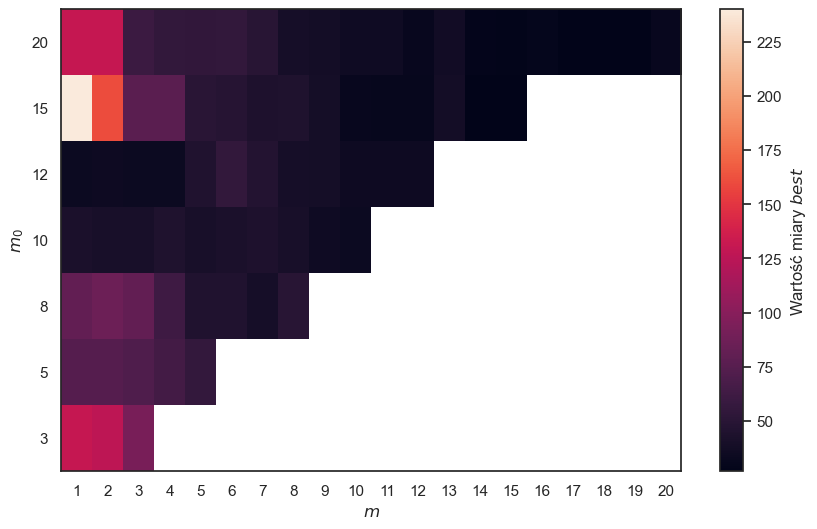

In [45]:
import numpy as np
df_500 = df_scale_free[df_scale_free['number_of_islands']==500].copy()

heatmap_data = df_500.pivot_table(
    index="m0",
    columns="m",
    values="best",
    aggfunc="min"   # albo "mean", jeśli masz wielokrotne rekordy dla tej samej konfiguracji
)

heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

plt.figure(figsize=(10, 6))
im = plt.imshow(heatmap_data, aspect="auto", origin="lower")

plt.colorbar(im, label=r"Wartość miary $\mathit{best}$")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel(r"$m$")
plt.ylabel(r"$m_0$")
# plt.title("Heatmapa wartości best dla topologii scale-free (500 wysp)")
plt.savefig(
    "heatmap_scale-free.pdf",
    bbox_inches="tight"
)

plt.show()




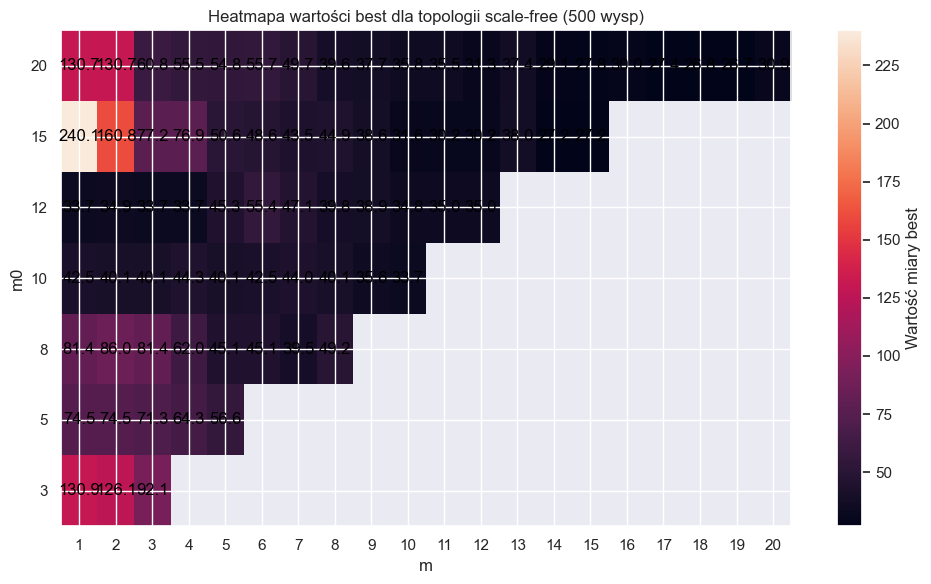

In [40]:

df_500 = df_scale_free[df_scale_free['number_of_islands']==500].copy()

heatmap_data = df_500.pivot_table(
    index="m0",
    columns="m",
    values="best",
    aggfunc="min"
)

heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_data, aspect="auto", origin="lower")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Wartość miary best")

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("m")
ax.set_ylabel("m0")
ax.set_title("Heatmapa wartości best dla topologii scale-free (500 wysp)")

# wpisywanie wartości do komórek
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [21]:
df_m0 = (
    df_scale_free[df_scale_free['number_of_islands']==500].groupby("m0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

# spłaszczenie nazw kolumn
df_m0.columns = [
    "_".join(col).strip("_")
    for col in df_m0.columns.values
]

df_m0

,m0,best_mean,best_min,best_max,best_std,average_mean,average_min,average_max,average_std
0,3,121.726807,92.122609,146.289448,22.993025,622.709551,319.835830,803.087625,222.871724
1,5,96.788095,56.588856,303.795157,74.067601,374.840825,153.541540,1149.722996,284.025375
2,8,61.217808,39.527732,86.040352,19.145261,252.608456,130.334723,383.426864,122.060855
3,10,40.300698,33.668706,44.292556,3.421213,224.043138,172.584034,426.517907,100.763140
4,12,38.926798,33.668706,55.352197,6.899969,222.020936,89.929764,473.034101,152.751084
5,15,64.364351,27.172644,240.081786,59.331137,252.469492,80.311423,1533.954249,381.088531
6,20,47.687997,26.702462,130.690038,30.421000,201.467592,65.058205,999.864218,275.374202


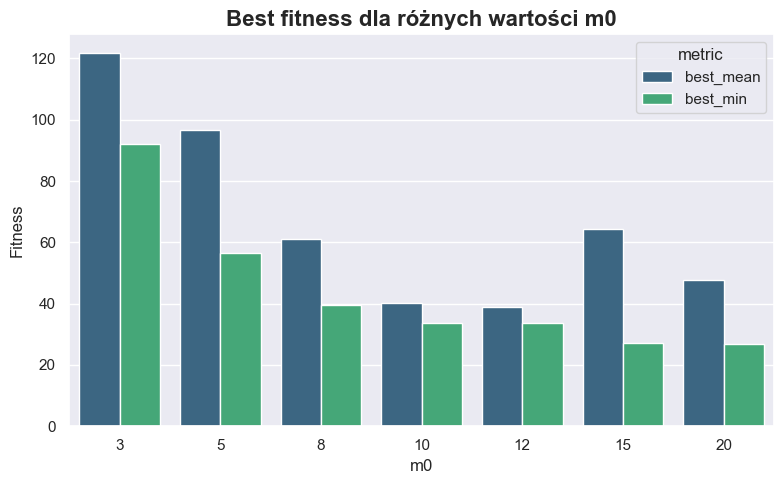

In [22]:
plot_df = df_m0.melt(
    id_vars="m0",
    value_vars=["best_mean", "best_min"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="m0",
    y="value",
    hue="metric",
    palette="viridis",
)

plt.title(
    "Best fitness dla różnych wartości m0",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("m0")
plt.ylabel("Fitness")

plt.tight_layout()
plt.show()

In [17]:
df_m = (
    df_scale_free[df_scale_free['number_of_islands']==500].groupby("m", as_index=False)
    .agg({
        "best": ["mean", "min"],
        "average": ["mean", "min"],
    })
)

# spłaszczenie nazw kolumn
df_m.columns = [
    "_".join(col).strip("_")
    for col in df_m.columns.values
]

df_m

,m,best_mean,best_min,average_mean,average_min
0,1,131.529951,33.668706,722.934714,174.506914
1,2,98.959770,34.927613,543.058323,174.369285
2,3,72.093628,33.668706,306.423534,173.858747
3,4,58.090472,33.668706,252.794175,174.977288
4,5,50.087587,40.133721,164.566478,122.079612
5,6,49.437188,42.466920,139.227465,113.539661
6,7,44.746555,39.527732,149.264994,119.536731
7,8,42.720990,39.589233,139.967962,110.053256
8,9,37.700943,35.581196,188.654579,87.157176
9,10,33.960781,31.559966,173.618199,86.816158


In [46]:
df_scale_free[df_scale_free["m"]==14]

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
38,13,scale_free,50,5,5,20,14,123.0,296.316443,244.561636,scale_free_n50_array_20259859.csv,NaN
57,73,scale_free,300,5,5,20,14,123.0,149.652190,70.276997,scale_free_n300_array_20259859.csv,NaN
116,72,scale_free,100,5,5,15,14,123.0,280.757831,177.415906,scale_free_n100_array_20256742.csv,NaN
130,53,scale_free,200,5,5,20,14,123.0,222.540273,112.289346,scale_free_n200_array_20259859.csv,NaN
171,35,scale_free,500,5,5,15,14,123.0,80.329760,27.172644,scale_free_n500_array_20258306.csv,NaN
209,109,scale_free,200,5,5,15,14,123.0,208.766875,98.236648,scale_free_n200_array_20256742.csv,NaN
226,33,scale_free,100,5,5,20,14,123.0,299.783244,198.350209,scale_free_n100_array_20259859.csv,NaN
268,93,scale_free,500,5,5,20,14,123.0,103.135627,29.057076,scale_free_n500_array_20259859.csv,NaN
308,146,scale_free,300,5,5,15,14,123.0,183.777577,74.955315,scale_free_n300_array_20256742.csv,NaN
348,35,scale_free,50,5,5,15,14,123.0,289.889903,252.725999,scale_free_n50_array_20256742.csv,NaN


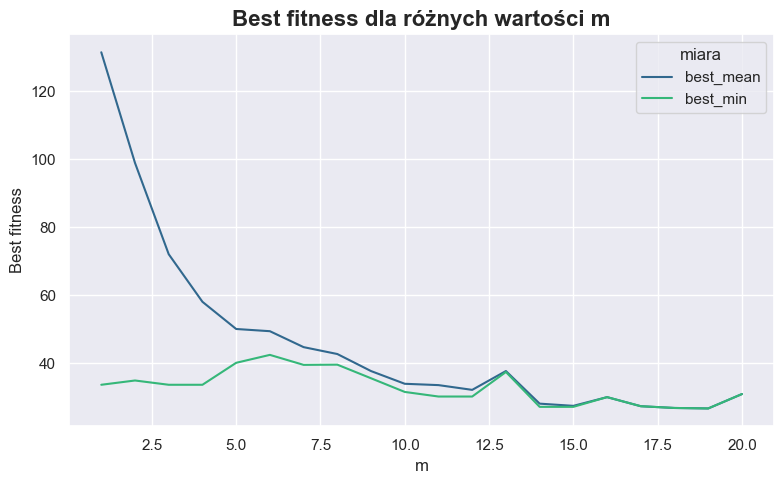

In [27]:
plot_df = df_m.melt(
    id_vars="m",
    value_vars=["best_mean", "best_min"],
    var_name="miara",
    value_name="value"
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=plot_df,
    x="m",
    y="value",
    hue="miara",
    palette="viridis",
    markers=["o", "v"],
)

plt.title(
    "Best fitness dla różnych wartości m",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("m")
plt.ylabel("Best fitness")

plt.tight_layout()
plt.show()

In [28]:
idx = df_scale_free.groupby("m0")["best"].idxmin()


df_scale_free.loc[idx][
    ["m0", "best", "number_of_islands", "m"]
].sort_values("best")


,m0,best,number_of_islands,m
273,20,26.702462,500,19
171,15,27.172644,500,14
146,10,33.668706,500,10
148,12,33.668706,500,3
13,8,39.527732,500,7
23,5,56.588856,500,5
17,3,92.122609,500,3


In [20]:
idx = df_scale_free.groupby("m")["best"].idxmin()

display(
    df_scale_free.loc[idx][
        ["m", "best", "number_of_islands", "m0"]
    ].sort_values("best")
)

,m,best,number_of_islands,m0
273,19,26.702462,500,20
272,18,26.841133,500,20
172,15,27.172644,500,15
171,14,27.172644,500,15
271,17,27.356576,500,20
270,16,30.031418,500,20
169,12,30.208750,500,15
170,11,30.208750,500,15
274,20,30.938436,500,20
168,10,31.559966,500,15


In [12]:
top3_per_islands = (
    df_scale_free
    .sort_values("best")
    .groupby("number_of_islands")
    .head(3)
)

top3_per_islands

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
273,98,scale_free,500,5,5,20,19,123.0,65.058205,26.702462,scale_free_n500_array_20259859.csv,NaN
272,97,scale_free,500,5,5,20,18,123.0,65.146290,26.841133,scale_free_n500_array_20259859.csv,NaN
171,35,scale_free,500,5,5,15,14,123.0,80.329760,27.172644,scale_free_n500_array_20258306.csv,NaN
311,147,scale_free,300,5,5,15,15,123.0,125.801400,56.556443,scale_free_n300_array_20256742.csv,NaN
376,62,scale_free,300,5,5,8,7,123.0,157.182988,60.824509,scale_free_n300_array_20089410.csv,NaN
377,63,scale_free,300,5,5,8,8,123.0,157.182988,60.824509,scale_free_n300_array_20089410.csv,NaN
209,109,scale_free,200,5,5,15,14,123.0,208.766875,98.236648,scale_free_n200_array_20256742.csv,NaN
193,94,scale_free,200,5,5,12,11,123.0,211.464441,103.082465,scale_free_n200_array_20256742.csv,NaN
210,110,scale_free,200,5,5,15,15,123.0,210.564089,105.340594,scale_free_n200_array_20256742.csv,NaN
225,34,scale_free,100,5,5,20,15,123.0,277.321397,174.921663,scale_free_n100_array_20259859.csv,NaN


In [13]:
best_cols = ['number_of_islands', 'm0', 'm', 'best', 'average']
out = top3_per_islands[best_cols].copy()
out

,number_of_islands,m0,m,best,average
273,500,20,19,26.702462,65.058205
272,500,20,18,26.841133,65.146290
171,500,15,14,27.172644,80.329760
311,300,15,15,56.556443,125.801400
376,300,8,7,60.824509,157.182988
377,300,8,8,60.824509,157.182988
209,200,15,14,98.236648,208.766875
193,200,12,11,103.082465,211.464441
210,200,15,15,105.340594,210.564089
225,100,20,15,174.921663,277.321397


In [36]:
param_cols = top3_per_islands.columns[2:7] # ignoruje pierwsze 2 i ostatnie 5 kolumn
#top10 = top10_per_islands[top10_per_islands['number_of_islands']==500]

out = top3_per_islands[param_cols].copy()
out["seed"] = 123

out_scale_free = out.loc[out.index.repeat(5)].reset_index(drop=True)

out_scale_free.to_csv(
    "top3_scale_new.txt",
    sep=" ",
    header=False,
    index=False
)

In [37]:
df_500 = (
    df_scale_free[df_scale_free["number_of_islands"] == 500]
    .sort_values("best")
    .reset_index(drop=True)
)

n = len(df_500)

selected = pd.concat([
    df_500.iloc[[0]],                           # best
    df_500.iloc[[int(0.5 * (n - 1))]],         # median
    df_500.iloc[[int(0.9 * (n - 1))]],         # weak
])

param_cols = selected.columns[2:7]

out = selected[param_cols].copy()
out["seed"] = 123

# każda konfiguracja 3 razy
out = out.loc[out.index.repeat(3)].reset_index(drop=True)

out.to_csv(
    "scale_free_500_best_median_weak.txt",
    sep=" ",
    header=False,
    index=False
)

## Wczytanie wyników dla topologii complete

In [38]:
files3 = glob.glob(os.path.join(RESULTS_PATH, "complete*.csv"))

print("Loaded files:")
for f in files3:
    print(os.path.basename(f))

dfs = []

for file in files3:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

print("\nColumns:")
print(df_complete.columns.tolist())

Loaded files:
complete_n500_array_20074995.csv
complete_n300_array_20074989.csv
complete_n100_array_20089275.csv
complete_n50_array_20074989.csv
complete_n500_array_20089275.csv
complete_n200_array_20074989.csv
complete_n50_array_20089275.csv
complete_n100_array_20074989.csv
complete_n300_array_20089275.csv
complete_n200_array_20089275.csv

Total rows: 55


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,build_target_ratio,average,best,source_file
0,local,complete,500,5,5,0.8,99.204916,46.661024,complete_n500_array_20074995.csv
1,3,complete,300,5,5,0.8,110.202610,59.757942,complete_n300_array_20074989.csv
2,10,complete,100,5,5,NaN,256.636619,194.201956,complete_n100_array_20089275.csv
3,11,complete,100,5,5,NaN,244.911136,188.233921,complete_n100_array_20089275.csv
4,12,complete,100,5,5,NaN,238.446188,183.901041,complete_n100_array_20089275.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'build_target_ratio', 'average', 'best', 'source_file']


# Porównanie różnych topologii (meeting, scale-free and complete)

In [39]:
df_meeting["topology"] = "meeting"
df_scale_free["topology"] = "scale_free"
df_complete["topology"] = "complete"

df_compare = pd.concat(
    [df_meeting, df_scale_free, df_complete],
    ignore_index=True
)

In [40]:
df_best_global = (
    df_compare.groupby("topology", as_index=False)
    .agg({
        "best": "min"
    })
)

display(df_best_global)

,topology,best
0,complete,36.862251
1,meeting,40.757107
2,scale_free,26.702462


In [41]:
df_islands_compare = (
    df_compare.groupby(
        ["topology", "number_of_islands"],
        as_index=False
    )
    .agg(
        best_mean=("best", "mean"),
        best_std=("best", "std"),
        best_min=("best", "min"),
        best_max=("best", "max"),
        best_median=("best", "median")
    )
)

display(df_islands_compare)

,topology,number_of_islands,best_mean,best_std,best_min,best_max,best_median
0,complete,50,241.699778,10.814668,219.601881,253.394104,244.700878
1,complete,100,185.043258,7.534414,178.323377,202.991137,183.901041
2,complete,200,113.818040,7.287132,104.953005,130.237059,111.647743
3,complete,300,69.781145,8.156221,59.757942,85.147444,68.333403
4,complete,500,42.289465,4.358031,36.862251,50.150453,39.787748
5,meeting,50,273.050723,12.455744,252.607229,292.914337,268.721847
6,meeting,100,220.874301,15.219260,200.337405,246.575509,223.002658
7,meeting,200,134.450687,12.613903,117.310979,151.841961,131.634465
8,meeting,300,87.083745,9.838783,66.554952,111.957236,89.558338
9,meeting,500,68.101952,14.579628,40.757107,94.388311,64.933504


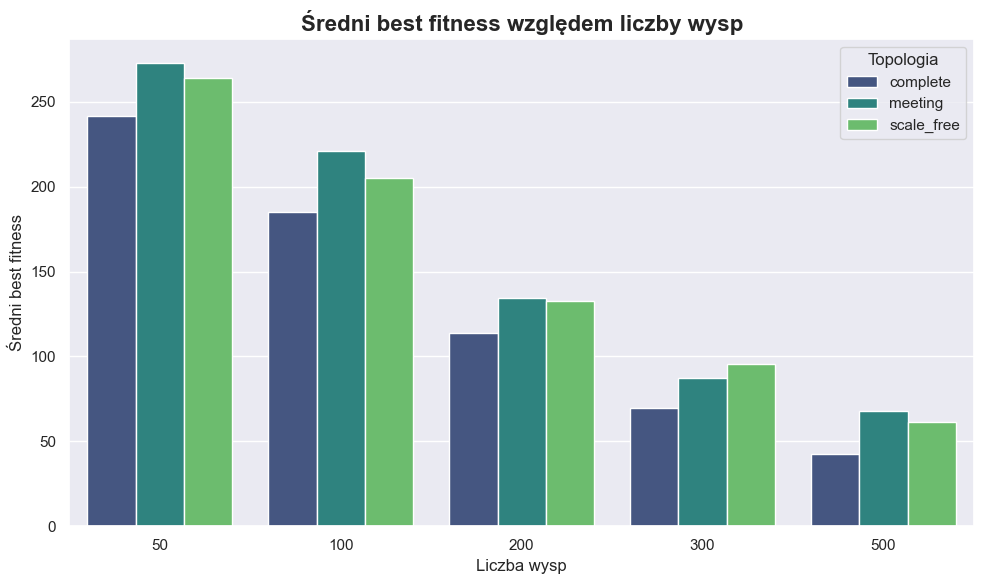

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="best_mean",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

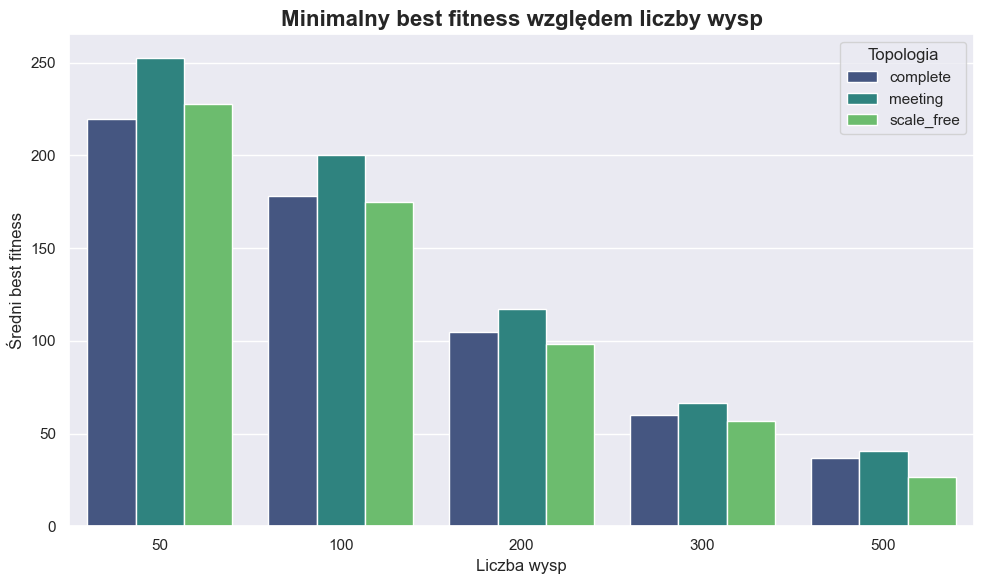

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="best_min",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Minimalny best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

In [44]:
top10 = (
    df_compare
    .sort_values("best")
    .head(10)
)

top10[["topology", "best", "average", "number_of_islands"]]

,topology,best,average,number_of_islands
421,scale_free,26.702462,65.058205,500
420,scale_free,26.841133,65.146290,500
320,scale_free,27.172644,80.311423,500
319,scale_free,27.172644,80.329760,500
419,scale_free,27.356576,65.582048,500
417,scale_free,27.757806,103.622994,500
416,scale_free,29.057076,103.135627,500
418,scale_free,30.031418,93.872196,500
318,scale_free,30.208750,99.250362,500
317,scale_free,30.208750,99.250362,500
